# Customer Intelligence & Segmentation Engine
### RFM Analysis + K-Means Clustering on Online Retail Data

---

| | |
|---|---|
| **Author** | Krupal Gohil |
| **Dataset** | [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) — 500K+ real transactions |
| **Techniques** | RFM Feature Engineering · K-Means Clustering · Outlier Segmentation · Churn Scoring |
| **Tools** | Python · Pandas · Scikit-Learn · Seaborn · Matplotlib |
| **Goal** | Segment ~4,300 customers into actionable groups to guide marketing strategy |

---

## Table of Contents
1. [Business Context & Questions](#1)
2. [Dataset Overview](#2)
3. [Imports & Configuration](#3)
4. [Data Loading & EDA](#4)
5. [Data Cleaning](#5)
6. [RFM Feature Engineering](#6)
7. [Log Transformation](#7)
8. [Outlier Handling](#8)
9. [Scaling & Preprocessing](#9)
10. [K-Means Model — Finding Optimal K](#10)
11. [Final Model & Cluster Visualisation](#11)
12. [Cluster Profiling & Labeling](#12)
13. [Premium Outlier Segments](#13)
14. [Churn Risk Scoring](#14)
15. [Final Segment Dashboard](#15)
16. [Business Recommendations](#16)
17. [Conclusion](#17)


---
<a id='1'></a>
## 1. Business Context & Questions

A UK-based online gift retailer sells to wholesalers across 40 countries. They have over 500,000 transactions but no clear picture of who their customers actually are. Without that, they can't target campaigns, identify churn risk, or reward their best buyers.

**This project answers:**

| # | Question |
|---|---------|
| Q1 | Which countries and products drive the most revenue? |
| Q2 | How many distinct customer types exist in the data? |
| Q3 | What behaviour defines each segment (spend, frequency, recency)? |
| Q4 | Which customers are at risk of churning right now? |
| Q5 | How should the marketing team prioritise their budget across segments? |


---
<a id='2'></a>
## 2. Dataset Overview

**Source:** [UCI Machine Learning Repository — Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

| Column | Description |
|--------|-------------|
| `Invoice` | 6-digit invoice number. Prefix `C` = cancellation, `A` = bad debt |
| `StockCode` | Product code |
| `Description` | Product name |
| `Quantity` | Units sold (negative = return) |
| `InvoiceDate` | Transaction timestamp |
| `Price` | Unit price in GBP (£) |
| `Customer ID` | Unique customer ID — nullable (guest checkouts have no ID) |
| `Country` | Customer country |

**Period:** December 2009 – December 2010 · **40 countries** · **~525,000 rows**


---
<a id='3'></a>
## 3. Imports & Configuration


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# File path — change this to your local path
DATA_PATH = 'online_retail_II.xlsx'


---
<a id='4'></a>
## 4. Data Loading & Exploratory Data Analysis

Before any modelling, we explore the raw data to understand its shape, quality, and key business patterns.


In [2]:
df = pd.read_excel(DATA_PATH, sheet_name=0)
df.shape


(525461, 8)

In [3]:
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [5]:
df.describe()


,Quantity,InvoiceDate,Price,Customer ID
count,525461.00,525461,525461.00,417534.00
mean,10.34,2010-06-28 11:37:36.845017856,4.69,15360.65
min,-9600.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-03-21 12:20:00,1.25,13983.00
50%,3.00,2010-07-06 09:51:00,2.10,15311.00
75%,10.00,2010-10-15 12:45:00,4.21,16799.00
max,19152.00,2010-12-09 20:01:00,25111.09,18287.00
std,107.42,NaN,146.13,1680.81


### EDA — Business Insights

**Q1: Which countries and products drive the most revenue?**

We compute a rough revenue proxy from the raw data (before cleaning) to answer this question.


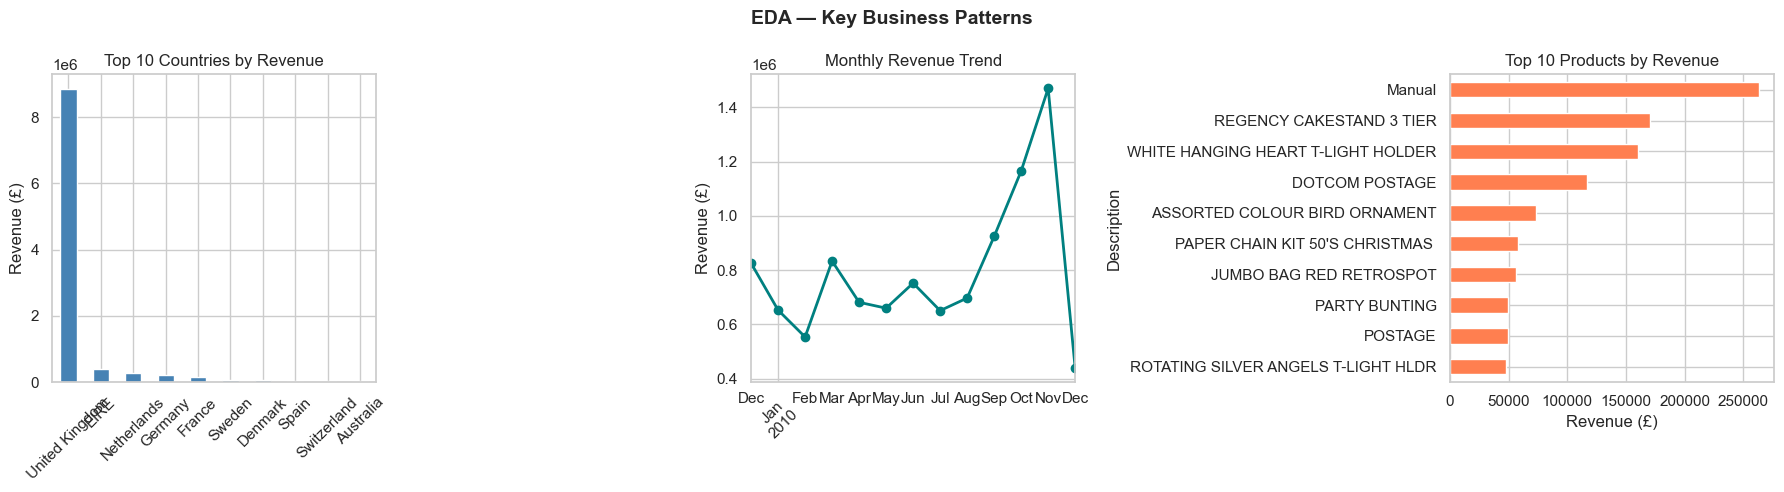

In [6]:
# Revenue proxy on raw data (before cleaning)
eda_df = df.copy()
eda_df['Revenue'] = eda_df['Quantity'] * eda_df['Price']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA — Key Business Patterns', fontsize=14, fontweight='bold')

# Top 10 countries by revenue
top_countries = (
    eda_df[eda_df['Revenue'] > 0]
    .groupby('Country')['Revenue'].sum()
    .sort_values(ascending=False)
    .head(10)
)
top_countries.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Countries by Revenue')
axes[0].set_xlabel('')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)

# Monthly sales trend
eda_df['Month'] = pd.to_datetime(eda_df['InvoiceDate']).dt.to_period('M')
monthly = eda_df[eda_df['Revenue'] > 0].groupby('Month')['Revenue'].sum()
monthly.plot(ax=axes[1], color='teal', marker='o', linewidth=2)
axes[1].set_title('Monthly Revenue Trend')
axes[1].set_xlabel('')
axes[1].set_ylabel('Revenue (£)')
axes[1].tick_params(axis='x', rotation=45)

# Top 10 products
top_products = (
    eda_df[eda_df['Revenue'] > 0]
    .groupby('Description')['Revenue'].sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products.plot(kind='barh', ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('Top 10 Products by Revenue')
axes[2].set_xlabel('Revenue (£)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


---
<a id='5'></a>
## 5. Data Cleaning

### What we remove and why

| Issue | Action | Reason |
|-------|--------|--------|
| Invoices starting with `C` | Remove | Cancellations, not purchases |
| Invoices starting with `A` | Remove | Bad debt adjustments (extreme negative prices) |
| Non-product StockCodes (DOT, D, M, etc.) | Remove | Internal charges, not customer purchases |
| Missing `Customer ID` | Remove | Guest checkouts can't be tracked in RFM |
| `Price == 0` | Remove | Free samples / admin entries distort monetary value |


In [7]:
cleaned_df = df.copy()

# Keep only 6-digit numeric invoices (removes C and A prefix)
cleaned_df['Invoice'] = cleaned_df['Invoice'].astype('str')
cleaned_df = cleaned_df[cleaned_df['Invoice'].str.match(r'^\d{6}$')]

# Keep only standard product StockCodes
cleaned_df['StockCode'] = cleaned_df['StockCode'].astype('str')
valid_stock = (
    cleaned_df['StockCode'].str.match(r'^\d{5}$') |
    cleaned_df['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$') |
    cleaned_df['StockCode'].str.match(r'^PADS$')
)
cleaned_df = cleaned_df[valid_stock]

# Drop missing Customer IDs and zero prices
cleaned_df.dropna(subset=['Customer ID'], inplace=True)
cleaned_df = cleaned_df[cleaned_df['Price'] > 0]

print(f"Raw rows    : {len(df):,}")
print(f"Clean rows  : {len(cleaned_df):,}")
print(f"Retained    : {len(cleaned_df)/len(df)*100:.1f}%")


Raw rows    : 525,461
Clean rows  : 406,309
Retained    : 77.3%


---
<a id='6'></a>
## 6. RFM Feature Engineering

**RFM** is an industry-standard customer scoring framework:

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Recency** | Days since last purchase | Lower = more recently active |
| **Frequency** | Count of unique invoices | Higher = more loyal |
| **Monetary** | Sum of (Price × Quantity) | Higher = more valuable |


In [8]:
cleaned_df = cleaned_df.copy()
cleaned_df['SalesLineTotal'] = cleaned_df['Price'] * cleaned_df['Quantity']

rfm = cleaned_df.groupby('Customer ID', as_index=False).agg(
    MonetaryValue=('SalesLineTotal', 'sum'),
    Frequency=('Invoice', 'nunique'),
    LastPurchase=('InvoiceDate', 'max')
)

snapshot_date = rfm['LastPurchase'].max()
rfm['Recency'] = (snapshot_date - rfm['LastPurchase']).dt.days
rfm.drop(columns='LastPurchase', inplace=True)

rfm.head()


,Customer ID,MonetaryValue,Frequency,Recency
0,12346.00,169.36,2,164
1,12347.00,1323.32,2,2
2,12348.00,221.16,1,73
3,12349.00,2221.14,2,42
4,12351.00,300.93,1,10


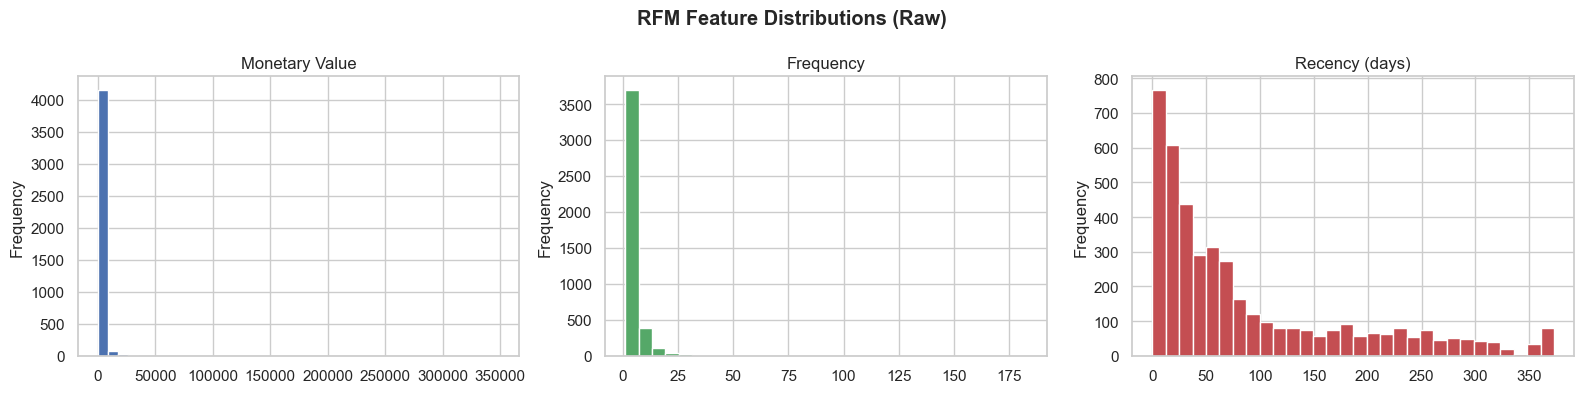

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('RFM Feature Distributions (Raw)', fontweight='bold')

rfm['MonetaryValue'].plot(kind='hist', bins=40, ax=axes[0], color='#4C72B0', edgecolor='white', title='Monetary Value')
rfm['Frequency'].plot(kind='hist', bins=30, ax=axes[1], color='#55A868', edgecolor='white', title='Frequency')
rfm['Recency'].plot(kind='hist', bins=30, ax=axes[2], color='#C44E52', edgecolor='white', title='Recency (days)')

plt.tight_layout()
plt.show()


---
<a id='7'></a>
## 7. Log Transformation

Both `MonetaryValue` and `Frequency` are **right-skewed** — a small number of customers spend/buy far more than everyone else. This skew causes K-Means to create poor clusters because the algorithm uses Euclidean distance.

`np.log1p()` compresses the long tail, giving K-Means a much fairer view of the data. We use `log1p` (log of value + 1) to safely handle any zero values.


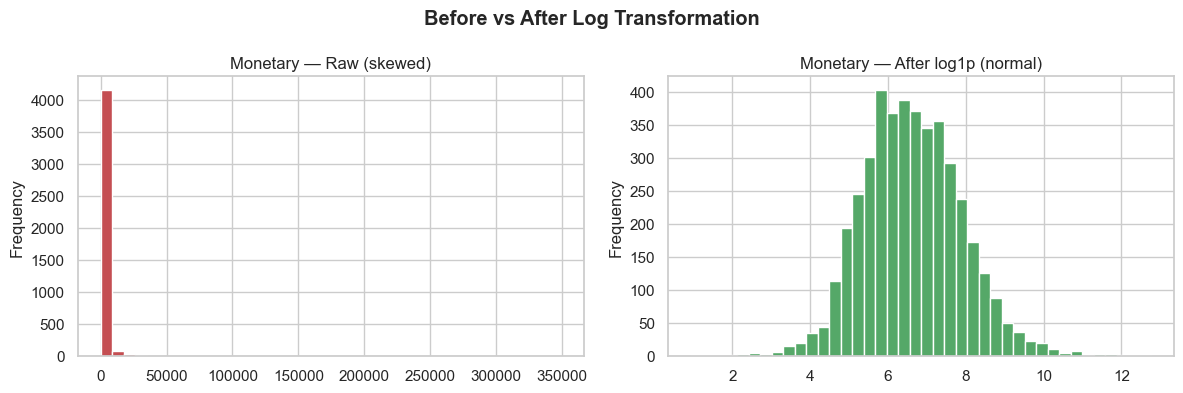

In [10]:
rfm_log = rfm.copy()
rfm_log['MonetaryValue'] = np.log1p(rfm_log['MonetaryValue'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Before vs After Log Transformation', fontweight='bold')

# Before
rfm['MonetaryValue'].plot(kind='hist', bins=40, ax=axes[0], color='#C44E52',
                          edgecolor='white', title='Monetary — Raw (skewed)')

# After
rfm_log['MonetaryValue'].plot(kind='hist', bins=40, ax=axes[1], color='#55A868',
                              edgecolor='white', title='Monetary — After log1p (normal)')
plt.tight_layout()
plt.show()


---
<a id='8'></a>
## 8. Outlier Handling

K-Means is pulled toward extreme values. We use the **IQR method** to identify outliers in `MonetaryValue` and `Frequency` and separate them into their own premium groups — rather than dropping them, because they represent the business's most valuable customers.


In [11]:
def get_iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

monetary_out = get_iqr_outliers(rfm_log['MonetaryValue'])
frequency_out = get_iqr_outliers(rfm_log['Frequency'])

outlier_mask = monetary_out | frequency_out
core_df = rfm_log[~outlier_mask].copy()
outlier_df = rfm[outlier_mask].copy()

print(f"Core customers    : {len(core_df):,}")
print(f"Outlier customers : {len(outlier_df):,}")


Core customers    : 4,213
Outlier customers : 72


---
<a id='9'></a>
## 9. Scaling & Preprocessing

K-Means uses Euclidean distance. Without scaling, `MonetaryValue` in pounds would dominate over `Recency` in days. `StandardScaler` transforms each feature to mean = 0, std = 1.


In [12]:
scaler = StandardScaler()
features = ['MonetaryValue', 'Frequency', 'Recency']

scaled = scaler.fit_transform(core_df[features])
scaled_df = pd.DataFrame(scaled, index=core_df.index, columns=features)

scaled_df.describe().round(2)


,MonetaryValue,Frequency,Recency
count,4213.00,4213.00,4213.00
mean,-0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-2.83,-1.03,-0.94
25%,-0.71,-1.03,-0.75
50%,-0.03,-0.38,-0.40
75%,0.70,0.72,0.47
max,2.90,3.34,2.94


---
<a id='10'></a>
## 10. K-Means Model — Finding Optimal K

We test K from 2 to 10 using two metrics:
- **Inertia (Elbow)** — lower is better; look for where the curve bends
- **Silhouette Score** — higher is better; measures how well-separated the clusters are


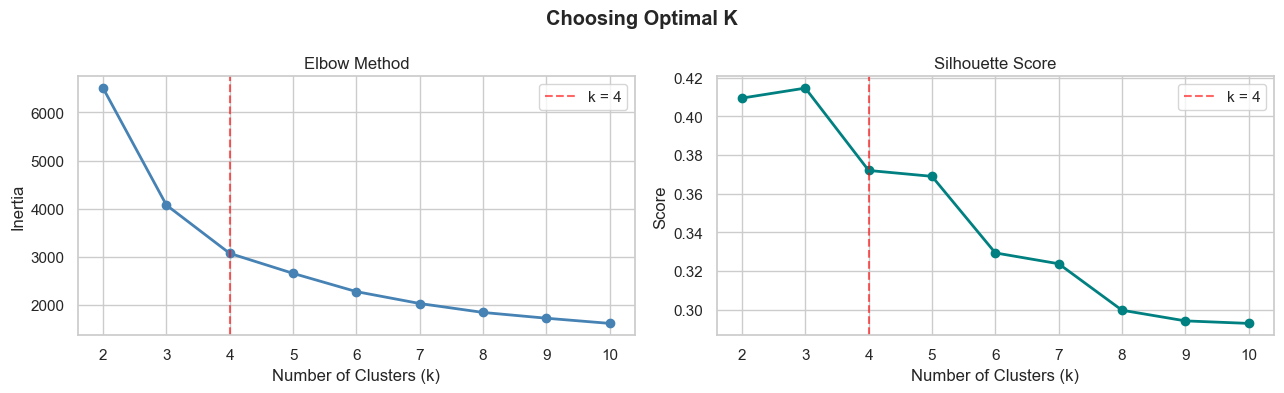

Best silhouette at k=3: 0.4146


In [13]:
inertia, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_df)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_df, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Choosing Optimal K', fontweight='bold')

ax1.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k = 4')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.legend()

ax2.plot(k_range, sil_scores, marker='o', color='teal', linewidth=2)
ax2.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k = 4')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Score')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Best silhouette at k={list(k_range)[sil_scores.index(max(sil_scores))]}: {max(sil_scores):.4f}")


---
<a id='11'></a>
## 11. Final Model & Cluster Visualisation

### Stability Check
Before trusting the model, we verify that K-Means produces consistent results across 10 different random starts. If silhouette scores are stable, the clusters are real — not a lucky split.


In [14]:
# Stability check — run 10 times, check silhouette consistency
stability = [
    silhouette_score(scaled_df, KMeans(n_clusters=4, random_state=i, n_init=10).fit_predict(scaled_df))
    for i in range(10)
]
print(f"Silhouette scores across 10 runs:")
print([round(s, 4) for s in stability])
print(f"Mean: {np.mean(stability):.4f}  |  Std: {np.std(stability):.4f}")


Silhouette scores across 10 runs:
[0.372, 0.372, 0.372, 0.372, 0.372, 0.372, 0.372, 0.3719, 0.3719, 0.372]
Mean: 0.3720  |  Std: 0.0000


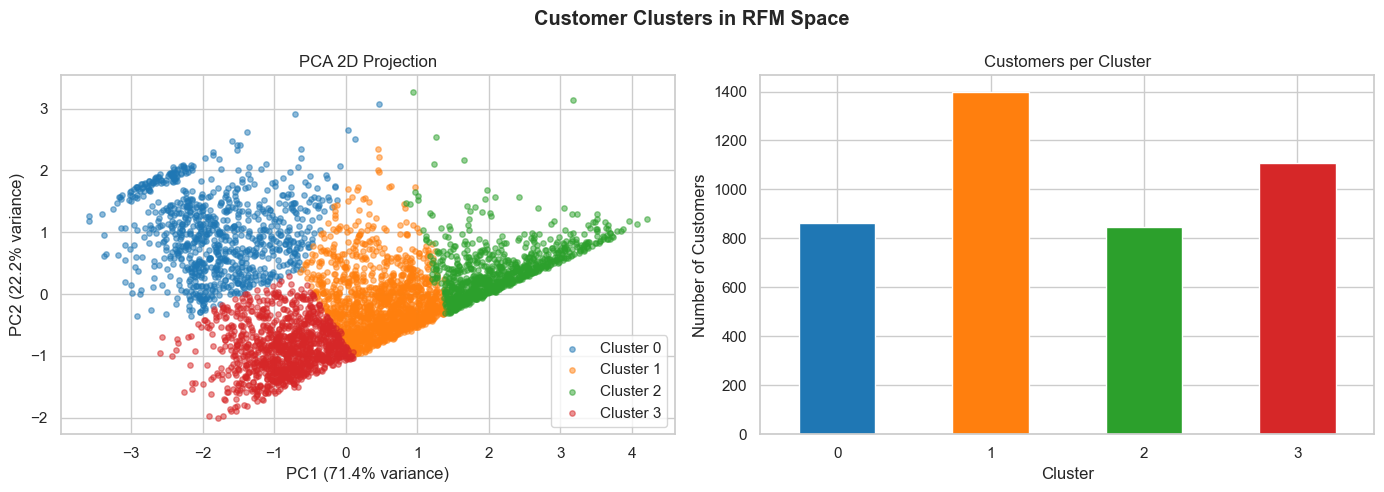

In [15]:
# Final model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
core_df = core_df.copy()
core_df['Cluster'] = kmeans.fit_predict(scaled_df)

# PCA 2D visualisation — easier to present than 3D
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'], index=core_df.index)
pca_df['Cluster'] = core_df['Cluster']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Clusters in RFM Space', fontweight='bold')

# PCA scatter
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for c in range(4):
    mask = pca_df['Cluster'] == c
    axes[0].scatter(pca_df[mask]['PC1'], pca_df[mask]['PC2'],
                    c=colors[c], label=f'Cluster {c}', alpha=0.5, s=15)
axes[0].set_title('PCA 2D Projection')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()

# Cluster sizes
core_df['Cluster'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Customers per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


---
<a id='12'></a>
## 12. Cluster Profiling & Labeling

We look at the mean RFM values per cluster to understand what each group looks like, then assign a clear business label.

> **Reading the table:** Low Recency = purchased recently (good). High Frequency = buys often (good). High Monetary = high spender (good).


In [16]:
# Use original (non-log) RFM values for interpretable means
core_df_orig = rfm[~outlier_mask].copy()
core_df_orig['Cluster'] = core_df['Cluster'].values

profile = core_df_orig.groupby('Cluster')[['Recency', 'Frequency', 'MonetaryValue']].mean().round(1)
profile['Size'] = core_df_orig['Cluster'].value_counts().sort_index()
profile


,Recency,Frequency,MonetaryValue,Size
Cluster,,,,
0,254.60,1.40,409.40,864
1,54.70,3.50,1248.80,1396
2,25.80,9.90,4253.40,845
3,55.60,1.40,317.70,1108


C:\Users\Jay\AppData\Local\Temp\ipykernel_17972\3009889553.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segment', y=feat, data=core_df_orig, palette=palette, ax=ax)
C:\Users\Jay\AppData\Local\Temp\ipykernel_17972\3009889553.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segment', y=feat, data=core_df_orig, palette=palette, ax=ax)
C:\Users\Jay\AppData\Local\Temp\ipykernel_17972\3009889553.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segment', y=feat, data=core_df_orig, palette=palette, ax=ax)


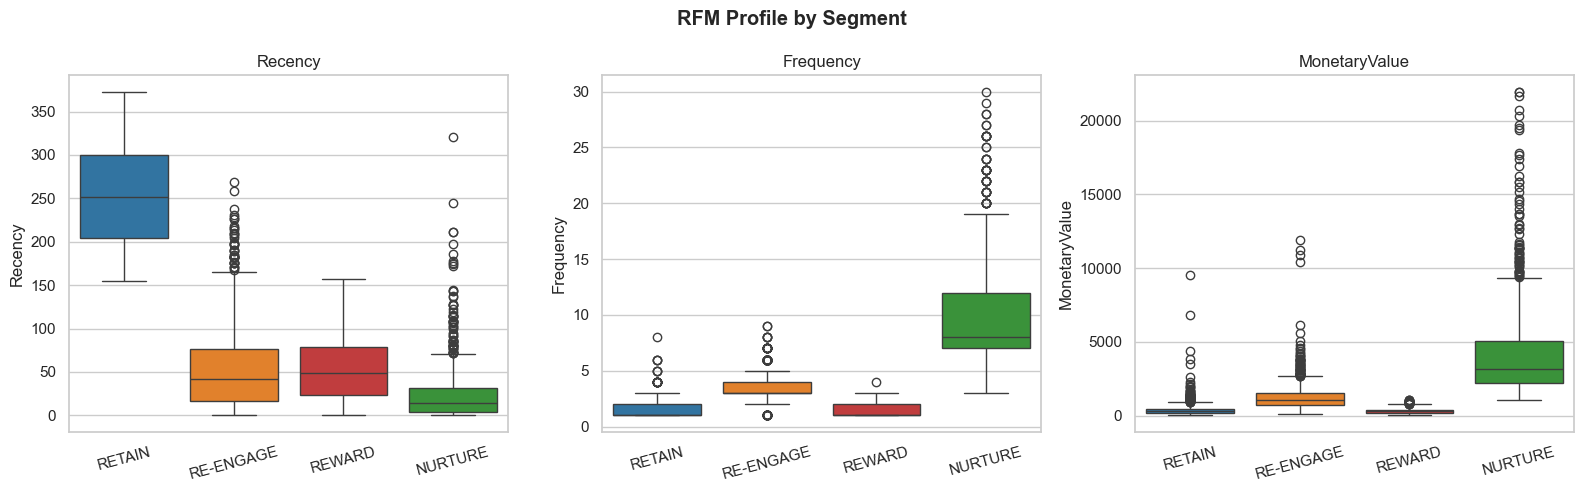

In [17]:
# Assign segment names based on cluster profiles
segment_map = {
    0: 'RETAIN',      # Mid-range — steady customers
    1: 'RE-ENGAGE',   # High recency — lapsed, at risk
    2: 'NURTURE',     # Low spend/freq — new or occasional
    3: 'REWARD'       # Low recency, decent spend — active loyalists
}

core_df_orig['Segment'] = core_df_orig['Cluster'].map(segment_map)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM Profile by Segment', fontweight='bold')

palette = {'RETAIN': '#1f77b4', 'RE-ENGAGE': '#ff7f0e', 'NURTURE': '#2ca02c', 'REWARD': '#d62728'}

for ax, feat in zip(axes, ['Recency', 'Frequency', 'MonetaryValue']):
    sns.boxplot(x='Segment', y=feat, data=core_df_orig, palette=palette, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


---
<a id='13'></a>
## 13. Premium Outlier Segments

Customers removed before K-Means (extreme spenders / frequent buyers) are the business's most valuable customers. We give them their own dedicated segments instead of lumping them together.

| Segment | Definition | Strategy |
|---------|-----------|---------|
| **PAMPER** | High monetary, normal frequency | Big-ticket buyers — exclusive bundles |
| **UPSELL** | High frequency, normal monetary | Buy often but cheap — grow basket size |
| **DELIGHT** | Both outliers | True VIPs — white-glove treatment |


In [18]:
outlier_df = rfm[outlier_mask].copy()

# Identify which outlier category each customer falls into
mon_out = get_iqr_outliers(rfm_log.loc[outlier_mask, 'MonetaryValue'])
freq_out = get_iqr_outliers(rfm_log.loc[outlier_mask, 'Frequency'])

def assign_premium(row_idx):
    m = mon_out.loc[row_idx] if row_idx in mon_out.index else False
    f = freq_out.loc[row_idx] if row_idx in freq_out.index else False
    if m and f:
        return 'DELIGHT'
    elif m:
        return 'PAMPER'
    else:
        return 'UPSELL'

outlier_df['Segment'] = [assign_premium(i) for i in outlier_df.index]
print(outlier_df['Segment'].value_counts().to_string())


Segment
UPSELL     58
DELIGHT    14


---
<a id='14'></a>
## 14. Churn Risk Scoring

Customers who haven't purchased recently are at risk of churning. We score each customer from 0–100 based on their Recency value.

- **Score 0** = purchased very recently (safe)
- **Score 100** = hasn't purchased in a very long time (high churn risk)

This gives the marketing team a **ranked priority list** for win-back campaigns.


In [19]:
# Combine core and outlier segments into one master dataframe
all_segments = pd.concat([
    core_df_orig[['Customer ID', 'Recency', 'Frequency', 'MonetaryValue', 'Segment']],
    outlier_df[['Customer ID', 'Recency', 'Frequency', 'MonetaryValue', 'Segment']]
])

# Churn score: normalise Recency to 0-100 (higher = more at risk)
max_rec = all_segments['Recency'].max()
all_segments['ChurnScore'] = (all_segments['Recency'] / max_rec * 100).round(1)

# Top 20 most at-risk customers
at_risk = (
    all_segments[all_segments['Segment'] == 'RE-ENGAGE']
    .sort_values('ChurnScore', ascending=False)
    .head(20)
    [['Customer ID', 'Recency', 'Frequency', 'MonetaryValue', 'ChurnScore']]
    .reset_index(drop=True)
)

at_risk


,Customer ID,Recency,Frequency,MonetaryValue,ChurnScore
0,18051.00,269,7,2282.28,72.10
1,15911.00,258,8,1685.89,69.20
2,17032.00,238,5,2916.97,63.80
3,13935.00,231,3,6116.92,61.90
4,13762.00,228,4,2165.76,61.10
5,16749.00,226,2,4387.08,60.60
6,18268.00,226,5,1464.73,60.60
7,13393.00,218,4,1131.45,58.40
8,17028.00,216,3,1593.83,57.90
9,17400.00,216,3,2547.09,57.90


C:\Users\Jay\AppData\Local\Temp\ipykernel_17972\180518042.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segment', y='ChurnScore', data=all_segments,


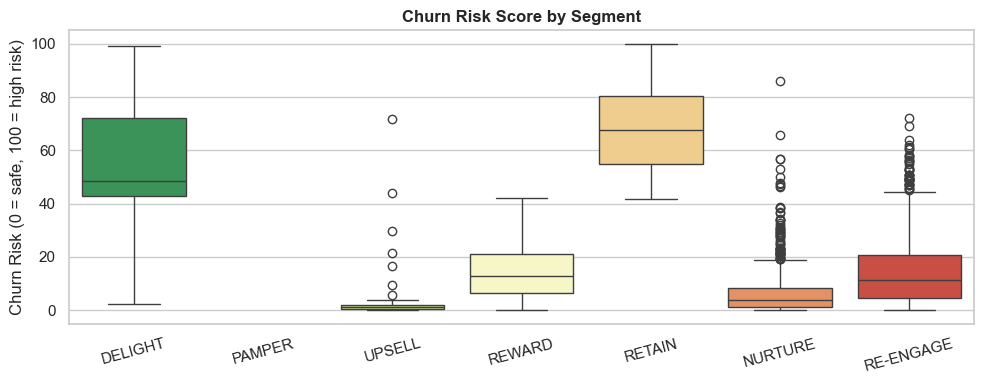

In [20]:
# Churn score distribution per segment
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x='Segment', y='ChurnScore', data=all_segments,
            order=['DELIGHT', 'PAMPER', 'UPSELL', 'REWARD', 'RETAIN', 'NURTURE', 'RE-ENGAGE'],
            palette='RdYlGn_r', ax=ax)
ax.set_title('Churn Risk Score by Segment', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Churn Risk (0 = safe, 100 = high risk)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


---
<a id='15'></a>
## 15. Final Segment Dashboard

All 7 segments combined — the single output a marketing team can act on.


In [21]:
segment_summary = all_segments.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('MonetaryValue', 'mean'),
    Avg_ChurnScore=('ChurnScore', 'mean')
).round(1).sort_values('Avg_Monetary', ascending=False)

segment_summary


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_ChurnScore
Segment,,,,,
UPSELL,58,16.50,51.80,45344.80,4.40
NURTURE,845,25.80,9.90,4253.40,6.90
RE-ENGAGE,1396,54.70,3.50,1248.80,14.70
RETAIN,864,254.60,1.40,409.40,68.30
REWARD,1108,55.60,1.40,317.70,14.90
DELIGHT,14,213.60,1.00,11.00,57.30


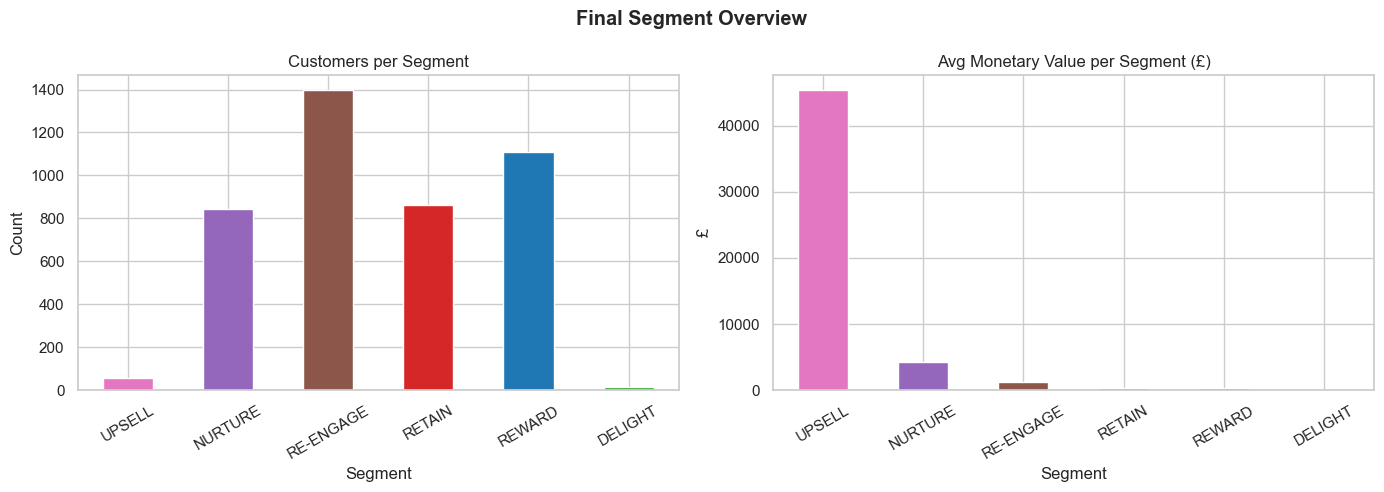

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Final Segment Overview', fontweight='bold')

seg_order = segment_summary.index.tolist()
colors_7 = ['#e377c2', '#9467bd', '#8c564b', '#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']

# Customer count
segment_summary['Customers'].plot(kind='bar', ax=axes[0], color=colors_7, edgecolor='white')
axes[0].set_title('Customers per Segment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Avg monetary
segment_summary['Avg_Monetary'].plot(kind='bar', ax=axes[1], color=colors_7, edgecolor='white')
axes[1].set_title('Avg Monetary Value per Segment (£)')
axes[1].set_ylabel('£')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


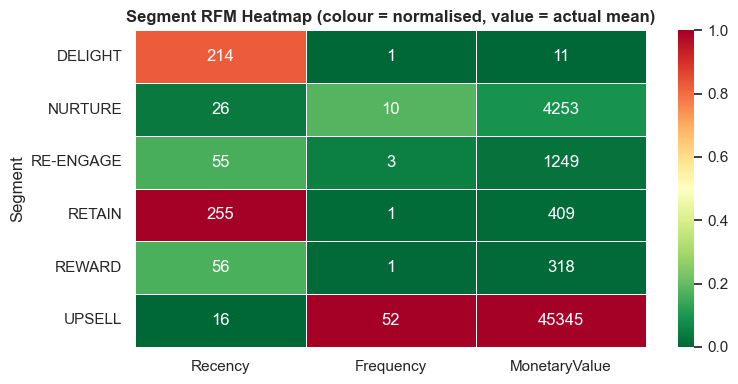

In [23]:
# Normalised heatmap — quick at-a-glance segment profiles
heat_data = all_segments.groupby('Segment')[['Recency', 'Frequency', 'MonetaryValue']].mean()
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

plt.figure(figsize=(8, 4))
sns.heatmap(heat_norm, annot=heat_data.round(0), fmt='.0f',
            cmap='RdYlGn_r', linewidths=0.5)
plt.title('Segment RFM Heatmap (colour = normalised, value = actual mean)', fontweight='bold')
plt.tight_layout()
plt.show()


---
<a id='16'></a>
## 16. Business Recommendations

| Segment | Size | Priority | Strategy |
|---------|------|----------|---------|
| **DELIGHT** | Small | Critical | VIP programme, dedicated account manager, early product access |
| **PAMPER** | Small | High | Premium bundles, seasonal outreach, volume pricing |
| **UPSELL** | Medium | High | Cross-sell higher-margin products, basket-size promotions |
| **REWARD** | Medium | High | Points-based loyalty scheme, referral bonuses |
| **RETAIN** | Large | Medium | Regular newsletters, seasonal promotions |
| **NURTURE** | Large | Medium | Onboarding emails, first-repeat-purchase discount |
| **RE-ENGAGE** | Medium | Low | Win-back campaign ("here's 20% off"), then survey why they left |

### Budget Allocation Suggestion

| Segment | Budget Share |
|---------|-------------|
| DELIGHT + PAMPER | 40% |
| UPSELL + REWARD | 30% |
| RETAIN + NURTURE | 20% |
| RE-ENGAGE | 10% |


---
<a id='17'></a>
## 17. Conclusion

| Item | Result |
|------|--------|
| Raw transactions | 525,461 |
| After cleaning | ~406,000 |
| Unique customers segmented | ~4,300 |
| Core K-Means clusters | 4 |
| Premium outlier segments | 3 |
| **Total named segments** | **7** |
| Optimal k (elbow + silhouette) | 4 |

This project demonstrates an end-to-end customer segmentation pipeline:
- Rigorous data cleaning on a messy real-world dataset
- RFM feature engineering with log transformation
- K-Means with stability validation and PCA visualisation
- Outlier handling that preserves VIP customer insight
- Churn risk scoring for direct business use

**The output is a ranked, labelled customer list that a marketing team can import into any CRM tool and act on immediately.**

---

*Dataset: UCI Online Retail II · Tools: Python, Pandas, Scikit-Learn, Seaborn*
